In [1]:
from IPython.display import display, HTML
display(HTML('<style>.container { width:100% !important; }</style>')) # change code & markdown block width
display(HTML('<style>.output_result { max-width:100% !important; }</style>')) # change output cells width

# Set global font properties
import matplotlib as mpl
mpl.rc('font', family='sans-serif', size=16)              # Base font family and size
mpl.rc('axes', titlesize=20, titleweight='bold')          # Subplot titles
mpl.rc('figure', titlesize=22, titleweight='bold')        # Suptitles

**Objectives:** Spectroscopic fitting with two Gaussians for each line using AI.

In [2]:
import yaml

# Load emission line information from YAML file
with open("../emline_infos.yaml") as file:
    try:
        emline_infos = yaml.safe_load(file)
    except yaml.YAMLError as exc:
        print(exc)

# Define constants
redshift = 0.0935275
c = 299792  # speed of light in km/s
v_systemic = c * redshift

# Function to convert velocity to gaussian mu in wavelength units
def vel2wave(vel, ln):
    wrest = emline_infos[ln]['wavelength']
    wobs = ((vel*(1 + redshift) + v_systemic) / c + 1) * wrest
    return wobs

# Function to convert dispersion to gaussian std in wavelength units
def dis2wave(dis, ln):
    wrest = emline_infos[ln]['wavelength']
    return (dis*(1+redshift)*wrest/c)


In [ ]:
from matplotlib import pyplot as plt

import numpy as np
from astropy.io import fits

fn = '../manga-9094-1902-LOGCUBE-HYB10-MILESHC-MASTARSSP.fits.gz'
obs = fits.open(fn)[1].data
stm = fits.open(fn)[10].data
mask =  fits.open(fn)[3].data
bad_bits = (mask != 0)   #finding the bad pixels
flux_m = np.ma.array(obs, mask=bad_bits) 
hdr = fits.open(fn)[1].header
wave = fits.open(fn)[5].data
ivar = fits.open(fn)[2].data  # 1/sigma^2
emline = flux_m-stm

channel_data = [ 
    {
        'title':'OII',
        'emlines': ['OIIa', 'OIIb'],
        'wl_c': 4085 # center wavelength of the spectral window
    }, {
        'title':r'H$\beta$',
        'emlines': ['Hbeta'],
        'wl_c': 5320
    }, {
        'title':'OIII',
        'emlines': ['OIIIa', 'OIIIb'],
        'wl_c': 5455
    }, {
        'emlines': ['NIIa', 'Halpha', 'NIIb'],
        'title':r'H$\alpha$+NII',
        'wl_c': 7185
    }, {
        'title':'SII',
        'emlines': ['SIIa', 'SIIb'],
        'wl_c': 7355
    }
]

from parameters import SpectralWindow

# Compute normalized coordinates from a given wavelength
def wl2x_(wl, wl_min, wl_max):
    return (wl - wl_min) / (wl_max - wl_min)

# Lambda function builder
def make_wl2x(wl_min, wl_max):
    return lambda wl : wl2x_(wl, wl_min, wl_max)

# Compute a wavelength from given normalized coordinates
def x2wl_(x, wl_min, wl_max):
    return wl_min + x * (wl_max - wl_min)

# Lambda function builder
def make_x2wl(wl_min, wl_max):
    return lambda x : x2wl_(x, wl_min, wl_max)

# Create a SpectralWindow from channel_data
def build_channel(title, emlines, wl_c, D):
    idx_c = np.argmin(abs(wave - wl_c))

    wl_min = wave[idx_c - D//2]
    wl_max = wave[idx_c + (D+1)//2]

    # Variables (wl_min, wl_max) must be stored in a closure
    # wl2x = make_wl2x(wl_min, wl_max)
    # x2wl = make_x2wl(wl_min, wl_max)
    
    idx = slice(idx_c - 50, idx_c + 50)

    wl = wave[idx]
    # x  = wl2x(wave[idx])

    return SpectralWindow(title, lims=(wl_min, wl_max), emlines=emlines, wl=wl, idx=idx)

# Create a dictionary of Channels (SpectralWindow)
channels = { data['title'] : build_channel(**data, D=100)
    for data in channel_data }

# Pixel indices
px, py = 19, 16
fig, axes = plt.subplots(1, len(channels), figsize=(25, 6), constrained_layout=True)  # Horizontal layout with 3 plots

fig.suptitle(f'Pixel ({px}, {py})')
for ax, ch in zip(axes, channels.values()):

    yline = emline[ch.idx, py, px]
    std_line = 1/np.sqrt(ivar[ch.idx, py, px])

    ax.errorbar(ch.wl, yline, yerr=std_line, color='black', marker='.', label='Observed')
    ax.set_title(ch.name)

    # Set primary x-axis (wl values; lower ticks)
    # ax.set_xlabel(r'$\lambda$')

    wl2x = make_wl2x(*ch.lims)
    x2wl = make_x2wl(*ch.lims)

    # Add secondary x-axis (x values; upper ticks)
    ax2 = ax.secondary_xaxis('top', functions=(wl2x, x2wl))
    # ax2.set_xlabel('normalized wl')

plt.show()

In [4]:
from parameters import Parameter, EmissionLine, GaussianSuperposition, ParameterMapping

GpL = 2; # Number of Gaussian components to fit per spectral line

# Different from "emline" variable which corresponds to observed emission line data
# The following parameters are defined automatically:
# key = (ln_name, parname, component) for each emline, each component, and for parname in {'amp', 'mu', 'sigma'}
emlines = [EmissionLine(
                    lname, 
                    emline_infos[lname]['wavelength'], 
                    ch.name, 
                    GpL, 
                    par_lims={ 'amp': (0, 10), 'mu': (-100, 100), 'sigma': (5, 100) }
                )
                for ch in channels.values() 
                for lname in ch.lines # (!) Note that the first for loop is evaluated first
            ]

# Define extra parameters that will be used to constrain the Gaussian line parameters
extra_parameters = [
    # Line-of-sight projection of velocity at pixel:
    # key = ('velocity', comp)
    Parameter(key=('velocity', 0), lims=(-1000, 1000)),
    Parameter(key=('velocity', 1), lims=(-1000, 1000)),
    
    # Dispersion of velocities at pixel:
    # key = ('dispersion', comp)
    Parameter(key=('dispersion', 0), lims=(50, 800)),
    Parameter(key=('dispersion', 1), lims=(50, 800)),
]

# Combine all parameters
parameters = [p for ln in emlines for p in ln.parameters] + extra_parameters

## Constraints:
# A dictionary of form { pattern: fun(par_dict, *key) }.
# Each (tied) parameter whose `key` matches `pattern` shall be assigned the result of evaluating `fun`.
# - The tuple `pattern` = (p_1, p_2, ..., p_n) has elements which are an exact value or the `None` wildcard;
# This wildcard matches any key. For instance, the pattern `(None, 'mu', None)` matches `('Halpha', 'mu', 0)`, `('OIII', 'mu', 1)`, etc.
# - The method `fun` takes in a dictionary of already assigned parameters, `par_dict`, and the `key` corresponding to the tied parameter to be assigned.
# Tied parameters should depend only on free parameters, otherwise behaviour is not guaranteed.

# We define constraints on velocity and dispersion.
# For this we can define the following functions:

# a) Function for converting velocity to Gaussian mean for given line
# def vel2mu(v, ln):
#     mu_wl = vel2wave(v, ln) # mean in wavelength units
#     ch = *(ch for ch in channels if ln in ch.emlines),
#     wl2x = channels[ch]['wl2x'] # normalization function from wavelength to [0, 1]
#     return wl2x(mu_wl)

# Corresponding constraint `fun`
def velocity_constraint(par_dict, *key):
    lname, parname, comp = key
    return vel2wave(par_dict['velocity', comp], lname)

# b) Function for converting dispersion to Gaussian std for given line
# def dis2sigma(v, ln):
#     sigma_wl = dis2wave(v, ln) # sigma in wavelength units
#     ch = *(ch for ch in channels if ln in ch.emlines),
#     wl2x = channels[ch]['wl2x'] # normalization function from wavelength to [0, 1]
#     return wl2x(sigma_wl)

# Corresponding constraint `fun`
def dispersion_constraint(par_dict, *key):
    lname, parname, comp = key
    return dis2wave(par_dict['dispersion', comp], lname)

# We now define the constraint dictionary using wildcards:
constraints = {
    (None, 'mu', None): velocity_constraint,
    (None, 'sigma', None): dispersion_constraint,
}
# Note that we could do the following instead, if we did not want to use wildcards:
# constraints = {
#     **{
#     (ln.name, 'mu', comp): velocity_constraint for ln in emlines for comp in [0, 1]
#     },
#     **{
#     (ln.name, 'sigma', comp): dispersion_constraint for ln in emlines for comp in [0, 1]
#     },
# }

# The ParameterMapping instance encodes how each parameter in network output is mapped onto each component in a spectral line
# Constraints are applied at this step to determine the non-free parameters of each Gaussian.
# Parameters are also normalized when feeding into the network, and denormalized after unpack.
parameter_mapping = ParameterMapping(parameters, constraints)

# The GaussianSuperposition instance reconstructs the spectral signal from the Gaussian parameters of each line
gaussian_model = GaussianSuperposition(emlines, channels, parameter_mapping)

print('Gaussian model:')
print('- Free parameters:', list(parameter_mapping.free_params))
print('- Tied parameters:', list(parameter_mapping.tied_params))
print('- Constraints:', parameter_mapping.constraints)


Gaussian model:
- Free parameters: [Parameter(key=('OIIa', 'amp', 0), lims=(0, 10)), Parameter(key=('OIIa', 'amp', 1), lims=(0, 10)), Parameter(key=('OIIb', 'amp', 0), lims=(0, 10)), Parameter(key=('OIIb', 'amp', 1), lims=(0, 10)), Parameter(key=('Hbeta', 'amp', 0), lims=(0, 10)), Parameter(key=('Hbeta', 'amp', 1), lims=(0, 10)), Parameter(key=('OIIIa', 'amp', 0), lims=(0, 10)), Parameter(key=('OIIIa', 'amp', 1), lims=(0, 10)), Parameter(key=('OIIIb', 'amp', 0), lims=(0, 10)), Parameter(key=('OIIIb', 'amp', 1), lims=(0, 10)), Parameter(key=('NIIa', 'amp', 0), lims=(0, 10)), Parameter(key=('NIIa', 'amp', 1), lims=(0, 10)), Parameter(key=('Halpha', 'amp', 0), lims=(0, 10)), Parameter(key=('Halpha', 'amp', 1), lims=(0, 10)), Parameter(key=('NIIb', 'amp', 0), lims=(0, 10)), Parameter(key=('NIIb', 'amp', 1), lims=(0, 10)), Parameter(key=('SIIa', 'amp', 0), lims=(0, 10)), Parameter(key=('SIIa', 'amp', 1), lims=(0, 10)), Parameter(key=('SIIb', 'amp', 0), lims=(0, 10)), Parameter(key=('SIIb', 

In [5]:
# N = Number of artificial training samples (i.e. independent spectra) to generate for training the network
# C = Number of channels (each channel is a window of spectral data containing at least one spectral line)
# D = Number of datapoints in each channel (~ spectral resolution)
N = 12800
C = len(channels)
D = 100

# The neural network can process multiple spectra at a time. The number of spectra processed simultaneously is called 'batch_size'
# The network input has shape (batch_size < N, channels = C, datapoints = D)
# The network output has shape (batch_size < N, total_free_parameters), where the total_free_parameter dimension is a vector with all the free parameters in the fitting model

L = len(emlines) # total number of lines
# G = GpL * L # total number of gaussians


## Artificial dataset

#### **Step 1:** Randomly generate free parameters.

#### **Step 2:** Sort the two Gaussians components ($\mu_1 < \mu_2$)
Sorting the two Gaussians is necessary to ensure non-degeneracy of inverse problem!

In this way our network learns how to output sorted gaussians.

Another option is to have a loss symmetric wrt the gaussian ordering. Then we don't care.

#### **Step 3:** Convert to pytorch

#### **Step 4:** Create spectroscopic data for model training.

In [6]:
import numpy as np

P = len(parameter_mapping.free_params) # number of free parameters in model

## Step 1 ##
# Randomly sample free parameters in our model

# Random number generator
rng = np.random.default_rng()

# Sample whole space between (min, max) = par.lims
par_dict = { 
    par.key: rng.uniform(*par.lims, size=N) 
    for par in parameter_mapping.free_params
}

## Step 2 ##
# Ensure that velocity of component 0 < velocity of component 1. 
# so that leftmost Gaussians are index 0.

keys = [('velocity', 0), ('velocity', 1)]
vels = [par_dict[key] for key in keys]

# Sort the Gaussian components for each sample
# (!) Note that in this step we are assuming that param.lims is the same for each velocity component
# Otherwise we would need to use a rejection sampling strategy
vels = np.sort(vels, axis=0)

# Update par_dict with sorted values
for i, key in enumerate(keys):
    par_dict[key] = vels[i]


## Step 3 ##

import torch

# Let us set up torch to use double (float64) by default:
torch.set_default_dtype(torch.float64)

# Convert data to PyTorch tensors
to_tensor = lambda arr: torch.tensor(arr, dtype=torch.float64)

# Updates the parameter dictionary to tensors
pars_dict = {
    key : to_tensor(val) for (key, val) in par_dict.items()
}

# Generate Gaussian signals

# Shape parameters into a tensor for use in the neural network
# Input dictionary should have sampled all the free parameters
pars = parameter_mapping.pack_tensor(pars_dict)

# Defensive programming: Ensure implementation of tensor packing / unpacking is giving correct results
# Delete this in final code
unpacked_dict = parameter_mapping.unpack_tensor(pars)
free_keys = {par.key for par in parameter_mapping.free_params}
unpacked_dict = {key: val for key, val in unpacked_dict.items() if key in free_keys}
assert pars_dict.keys() == unpacked_dict.keys(), f'Keys mismatch: {pars_dict.keys()} != {unpacked_dict.keys()}'
assert all(torch.equal(pars_dict[key], unpacked_dict[key]) for key in unpacked_dict.keys()), f'Parameter tensor packing issue! {
    [key for key in unpacked_dict.keys() if not torch.equal(pars_dict[key], unpacked_dict[key])]
}'
pars_dict = parameter_mapping.unpack_tensor(pars)

# Setup domain of signal (wavelength interval) in each channel
wl = np.stack([ch.wl for ch in channels.values()])
wl = to_tensor(wl)
wl = wl.expand(1, C, D)

# Normalized wavelengths for each channel
# x = np.linspace(-1, 1, D, axis=-1) 
# x  = np.stack([ch.x  for ch in channels.values()])
# x  = to_tensor(x)
# x = x.expand(1, C, D)

# Calculate the Gaussian components: use wavelength
y = gaussian_model.components(wl, pars) # (N, C, LpC, KpL, D)

# Calculate superposed spectrum: use wavelength
z = gaussian_model(wl, pars) # output shape (N, C, D)

assert z.shape == (N, C, D), f'Spectrum is not in expected shape! (shape = {z.shape}, expected = {(N, C, D)})'

# Add optional noise
w_std = 0.5e-2 * np.ones((N, C, D)) # to simplify, we use uniform amplitude across channels
w = rng.normal(scale=w_std) # normal distribution of noise, independently sampled for each wavelength
w = to_tensor(w)

z = z + w
# snr = z / noise_std * np.max(noise_std)

Sample data plot:

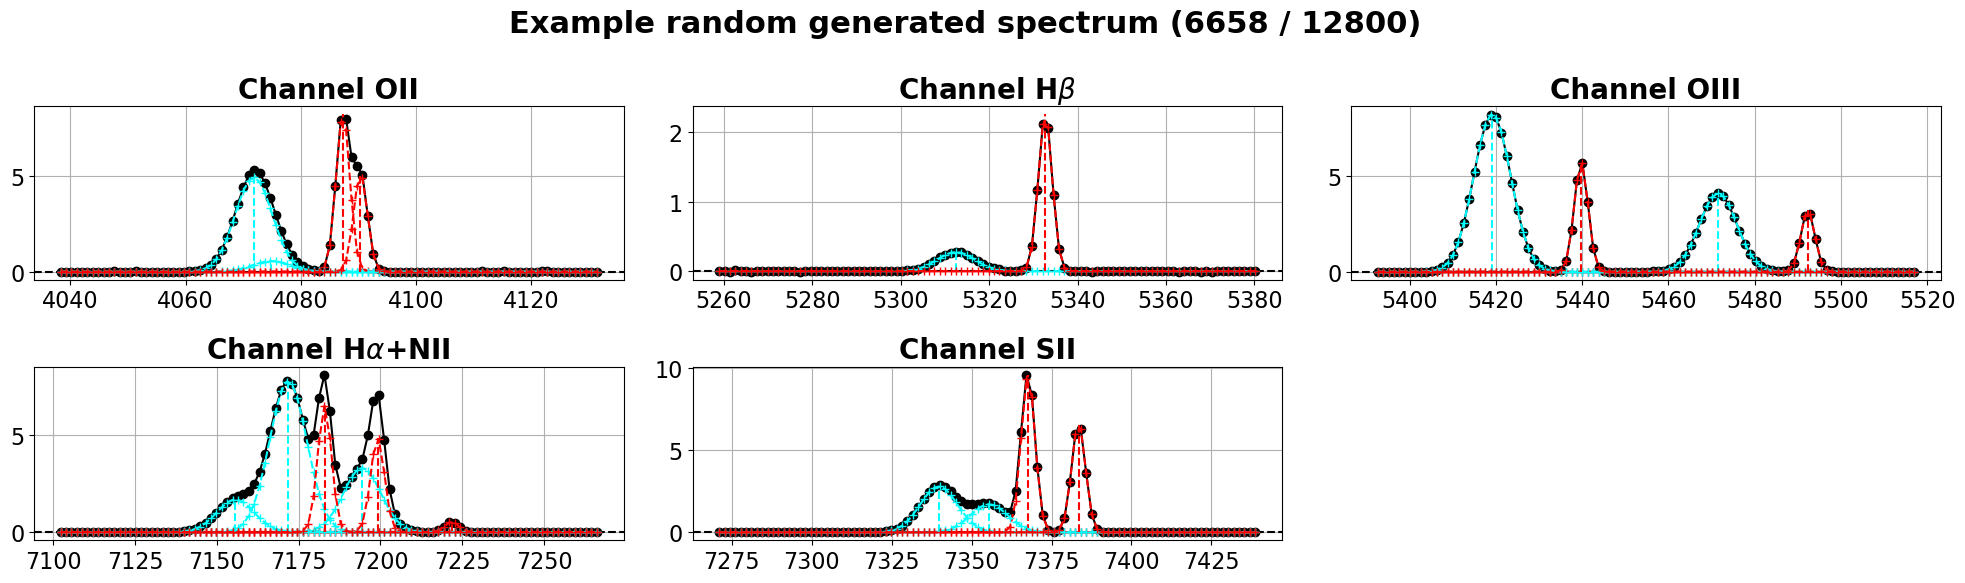

EXAMPLE DATA (6658 / 12800):

* Velocities:
    [-281.5853932416301, 857.7732218510407]
* Dispersion:
    [237.61531120884146, 88.24117132632756]
* Amplitudes:
    Channel 0: [4.907786173551935, 8.192672639590963],
    Channel 1: [0.5522815424904348, 5.078860897948613],
    Channel 2: [0.27418430439973607, 2.2594442465895206],
    Channel 3: [4.1169348657904585, 3.2215422190069387],
    Channel 4: [8.265320756883836, 5.778844200280235],
    Channel 5: [3.324199732121096, 0.5218642257449946],
    Channel 6: [7.805807137884796, 4.870702428223184],
    Channel 7: [1.677720360288747, 6.520840887485163],
    Channel 8: [2.7880545185307106, 9.575820890757718],
    Channel 9: [1.7009555041513291, 6.643130226771782],


In [7]:
from matplotlib import pyplot as plt

sample = rng.integers(N)


plt.figure(figsize=(20, 6))
plt.suptitle(f'Example random generated spectrum ({sample+1} / {N})')
for ch_idx, ch in enumerate(channels.values()):
  ax = plt.subplot((C+2)//3, 3, ch_idx+1)
  ax.set_title(f'Channel {ch.name}')
  # plt.plot(x, snr[sample, ch_idx], color='grey')
  plt.plot(wl[0, ch_idx], z[sample, ch_idx], color='black', marker='o')
  plt.axhline(0, 0, 1, color='black', linestyle='--')
  for line_idx, line_name in enumerate(ch.lines):
    for comp_idx, color in zip(range(GpL), ['cyan', 'red']):
      plt.plot(wl[0, ch_idx], y[sample, ch_idx, line_idx, comp_idx], color=color, linestyle='dashed', marker='+')
      plt.vlines(pars_dict[line_name, 'mu', comp_idx][sample], 0, pars_dict[line_name, 'amp', comp_idx][sample], colors=color, linestyles='--')
  plt.grid(True)

# plt.xlabel('x')
# plt.ylabel('y')
plt.tight_layout()
plt.show()

print(f'EXAMPLE DATA ({sample+1} / {N}):\n')
print('* Velocities:', f'    {[par_dict['velocity', c][sample] for c in (0, 1)]}', sep='\n')
print('* Dispersion:', f'    {[par_dict['dispersion', c][sample] for c in (0, 1)]}', sep='\n')
print('* Amplitudes:', *(f'    Channel {i}: {[par_dict[ln.name, 'amp', c][sample] for c in (0, 1)]},' for i, ln in enumerate(emlines)), sep='\n')
# print('Means:', *(f'    Channel -: {val},' for i, val in enumerate(zip(*mu[sample]))), sep='\n')
# print('Stdevs:', *(f'    Channel {i}: {val},' for i, val in enumerate(zip(*sigma[sample]))), sep='\n')

**Step 2.** Define the neural network model.

In [8]:
import torch.nn.functional as F

# Define loss function
def criterion(output, target, x, weights=(0.2, 1), reduction = 'mean'):
    '''
    output, target: parameter tensors of network (N, P) 
    '''
    z_out = gaussian_model(x, output)
    z_tar = gaussian_model(x, target)

    loss_signal = F.mse_loss(z_out, z_tar, reduction=reduction)

    loss_pars = F.mse_loss(output, target, reduction=reduction)

    w_sum = sum(weights)
    return loss_signal*weights[0]/w_sum, loss_pars*weights[1]/w_sum


**Next steps:** Use the generated dataset and train the model to learn the Gaussian parameters from the spectroscopic signal.

In [9]:
import torch
import torch.optim as optim
from torch.utils.data import TensorDataset, Subset, DataLoader

from models import CoordGaussNet
from optim import EarlyStopping

# Choose model
# We are using the Coordinate Convolution model
# However, we are currently assuming a linear partition of the wavelengths (which is not strictly the case)
# We can also test Conv1d groups = C
model = CoordGaussNet(C, P, D)
print('Model architecture', f'({sum(p.numel() for p in model.parameters())} parameters):')
print(model)

# Determine if GPU (CUDA) is available and move data to device
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'Device setup: {device}.')

wl = wl.to(device)
# x = x.to(device)
z = z.to(device)
pars = pars.to(device)
model.to(device)

# Create the training and test datasets
dataset = TensorDataset(z, pars)
split = (N*8)//10
train_data = Subset(dataset, range(0, split))
test_data = Subset(dataset, range(split, N))

# Create a DataLoader
batch_size = 256
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size)

# Choose optimizer configuration
optimizer = optim.Adam(model.parameters(), lr=0.5e-3, weight_decay=1e-3, amsgrad=True)

# LR Scheduler reduces the learning rate when the training plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.3, patience=10, threshold=3e-3, verbose=True)

# Early stopping
early_stopping = EarlyStopping(patience=25, min_delta=1e-4, mode='min')  # Mode 'min' for minimizing loss

# Save errors for plotting
history = {
    'epochs': [],
    'train_loss': [],
    'test_loss': []
}

# Evaluate error on untrained model (epoch 0)
with torch.no_grad():

    model.eval()  # Set model to evaluation mode

    train_loss = 0.0
    for signal, params in train_loader:
        output = model(signal)
        train_loss += sum(criterion(output, params, wl))
    train_loss /= len(train_loader)

    test_loss = 0.0
    for signal, params in test_loader:
        output = model(signal)
        test_loss += sum(criterion(output, params, wl))
    test_loss /= len(test_loader)

    history['epochs'].append(0)
    history['train_loss'].append(train_loss.item())
    history['test_loss'].append(test_loss.item())

    print(f'Loss at epoch 0: Training {train_loss.item():.4f} | Test {test_loss:.4f}')

Model architecture (2702984 parameters):
CoordGaussNet(
  (conv1a): CoordConv1d(5, 40, kernel_size=(3,), stride=(1,), padding=(1,), dilation=(1,), groups=1, bias=False)
  (bn1a): BatchNorm1d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1b): CoordConv1d(40, 80, kernel_size=(3,), stride=(1,), padding=(1,), dilation=(1,), groups=1, bias=False)
  (bn1b): BatchNorm1d(80, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2a): CoordConv1d(80, 160, kernel_size=(3,), stride=(1,), padding=(1,), dilation=(1,), groups=1, bias=False)
  (bn2a): BatchNorm1d(160, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2b): CoordConv1d(160, 160, kernel_size=(3,), stride=(1,), padding=(1,), dilation=(1,), groups=1, bias=False)
  (bn2b): BatchNorm1d(160, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel_size=2, st

c:\ProgramData\anaconda3\envs\Aashiya\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Loss at epoch 0: Training 4.6689 | Test 4.7386


In [ ]:
# Training loop
start_epoch = history['epochs'][-1] + 1
train_duration = 200
history_skip = 1
for epoch in range(start_epoch, start_epoch + train_duration):
  model.train()
  train_loss = 0.0
  for signal, params in train_loader:
    optimizer.zero_grad()
    output = model(signal)
    loss = sum(criterion(output, params, wl))
    loss.backward()
    optimizer.step()
    train_loss += loss.item()
  train_loss /= len(train_loader)

  # Evaluate the model on the test set every few epochs
  if epoch % history_skip == 0:
    model.eval()  # Set model to evaluation mode
    test_loss = 0.0
    with torch.no_grad():
      for signal, params in test_loader:
        output = model(signal)
        loss = sum(criterion(output, params, wl, weights=(0, 1)))
        test_loss += loss.item()
    test_loss /= len(test_loader)

    # Save metadata to history dict
    history['epochs'].append(epoch)
    history['train_loss'].append(train_loss)
    history['test_loss'].append(test_loss)

    print(f'[Loss at epoch {epoch} / {start_epoch + train_duration - 1}], Training: {train_loss:.6f}, Test: {test_loss:.6f}. LR({scheduler.get_last_lr()[0]:.2e})')

    # Check for early stopping
    early_stopping(test_loss)
    if early_stopping.early_stop:
        print(f"Early stopping at epoch {epoch}")
        break

    # Update learning rate
    scheduler.step(test_loss)

print('Finished Training')


from datetime import datetime

timestamp = datetime.today().strftime('%Y-%m-%d_%H-%M-%S')
path = f'./nnet/models/gnet_{timestamp}.pt'
save_model = True
if save_model:  
  torch.save(model.state_dict(), path)
  print(f'The model has been saved to path {path}')

[Loss at epoch 1 / 200], Training: 1.480181, Test: 0.191023. LR(5.00e-04)
[Loss at epoch 2 / 200], Training: 0.507076, Test: 0.122642. LR(5.00e-04)
[Loss at epoch 3 / 200], Training: 0.395280, Test: 0.114360. LR(5.00e-04)
[Loss at epoch 4 / 200], Training: 0.337367, Test: 0.115027. LR(5.00e-04)
[Loss at epoch 5 / 200], Training: 0.309812, Test: 0.107139. LR(5.00e-04)
[Loss at epoch 6 / 200], Training: 0.289595, Test: 0.102886. LR(5.00e-04)
[Loss at epoch 7 / 200], Training: 0.273381, Test: 0.106809. LR(5.00e-04)
[Loss at epoch 8 / 200], Training: 0.264653, Test: 0.108527. LR(5.00e-04)
[Loss at epoch 9 / 200], Training: 0.259818, Test: 0.103348. LR(5.00e-04)
[Loss at epoch 10 / 200], Training: 0.266208, Test: 0.108223. LR(5.00e-04)
[Loss at epoch 11 / 200], Training: 0.261225, Test: 0.102212. LR(5.00e-04)
[Loss at epoch 12 / 200], Training: 0.249884, Test: 0.099391. LR(5.00e-04)
[Loss at epoch 13 / 200], Training: 0.243720, Test: 0.104432. LR(5.00e-04)
[Loss at epoch 14 / 200], Training

RuntimeError: Parent directory ./models does not exist.

Summary:
  Epochs: 96
  Min train loss: 1.299e-01
  Min test loss: 8.600e-02


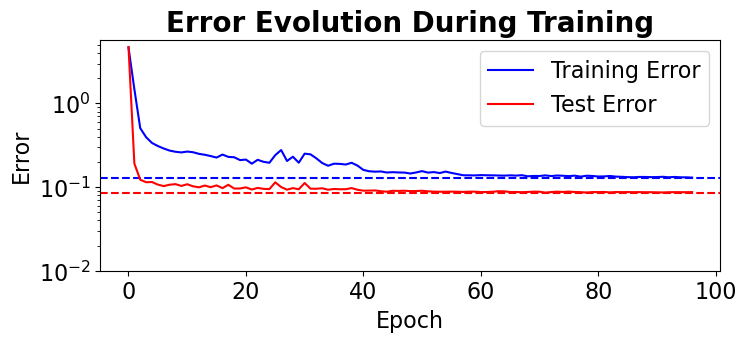

In [15]:
min_train = min(*history['train_loss'])
min_test = min(*history['test_loss'])

print('Summary:', f'  Epochs: {max(*history['epochs'])}', f'  Min train loss: {min_train:.3e}', f'  Min test loss: {min_test:.3e}',sep='\n')

# "nearest power of 10 less than x"
floor10 = lambda x : 10**(np.log10(x)//1)

plt.figure(figsize=(8, 3))
# plt.axhline(min(*history['train_loss'], *history['test_loss']), color='k')
plt.axhline(min_train, color='b', linestyle='--')
plt.axhline(min_test, color='r', linestyle='--')
plt.plot(history['epochs'], history['train_loss'], label="Training Error", color = 'b')
plt.plot(history['epochs'], history['test_loss'], label="Test Error", color = 'r')
plt.yscale('log')
plt.ylim(floor10(min(min_train, min_test)), None)
plt.xlabel("Epoch")
plt.ylabel("Error")
plt.title("Error Evolution During Training")
plt.legend()
plt.show()

In [16]:
if True:
    model.load_state_dict(torch.load(path, weights_only=True))
    model.eval()

Plot a sample of spectra, comparing the generated data and the output of the network.

Fit epoch 1: loss = 2.104e-01
Fit epoch 2: loss = 1.681e-01
Fit epoch 3: loss = 1.458e-01
Fit epoch 4: loss = 1.327e-01
Fit epoch 5: loss = 1.230e-01
Fit epoch 6: loss = 1.134e-01
Fit epoch 7: loss = 1.042e-01
Fit epoch 8: loss = 9.661e-02
Fit epoch 9: loss = 9.048e-02
Fit epoch 10: loss = 8.482e-02
Fit epoch 11: loss = 7.941e-02
Fit epoch 12: loss = 7.461e-02
Fit epoch 13: loss = 7.058e-02
Fit epoch 14: loss = 6.702e-02
Fit epoch 15: loss = 6.359e-02
Fit epoch 16: loss = 6.026e-02
Fit epoch 17: loss = 5.721e-02
Fit epoch 18: loss = 5.442e-02
Fit epoch 19: loss = 5.179e-02
Fit epoch 20: loss = 4.929e-02
Fit epoch 21: loss = 4.695e-02
Fit epoch 22: loss = 4.479e-02
Fit epoch 23: loss = 4.274e-02
Fit epoch 24: loss = 4.077e-02
Fit epoch 25: loss = 3.889e-02
Fit epoch 26: loss = 3.714e-02
Fit epoch 27: loss = 3.554e-02
Fit epoch 28: loss = 3.403e-02
Fit epoch 29: loss = 3.262e-02
Fit epoch 30: loss = 3.131e-02
Fit epoch 31: loss = 3.009e-02
Fit epoch 32: loss = 2.893e-02
Fit epoch 33: los

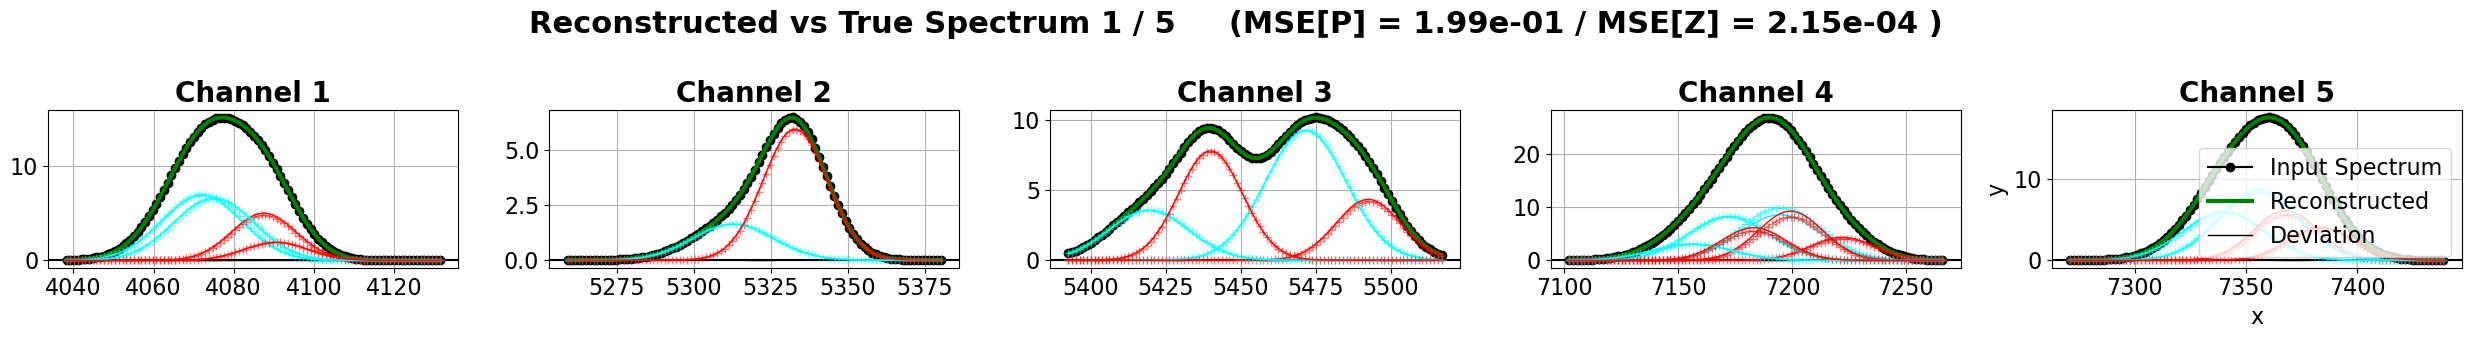

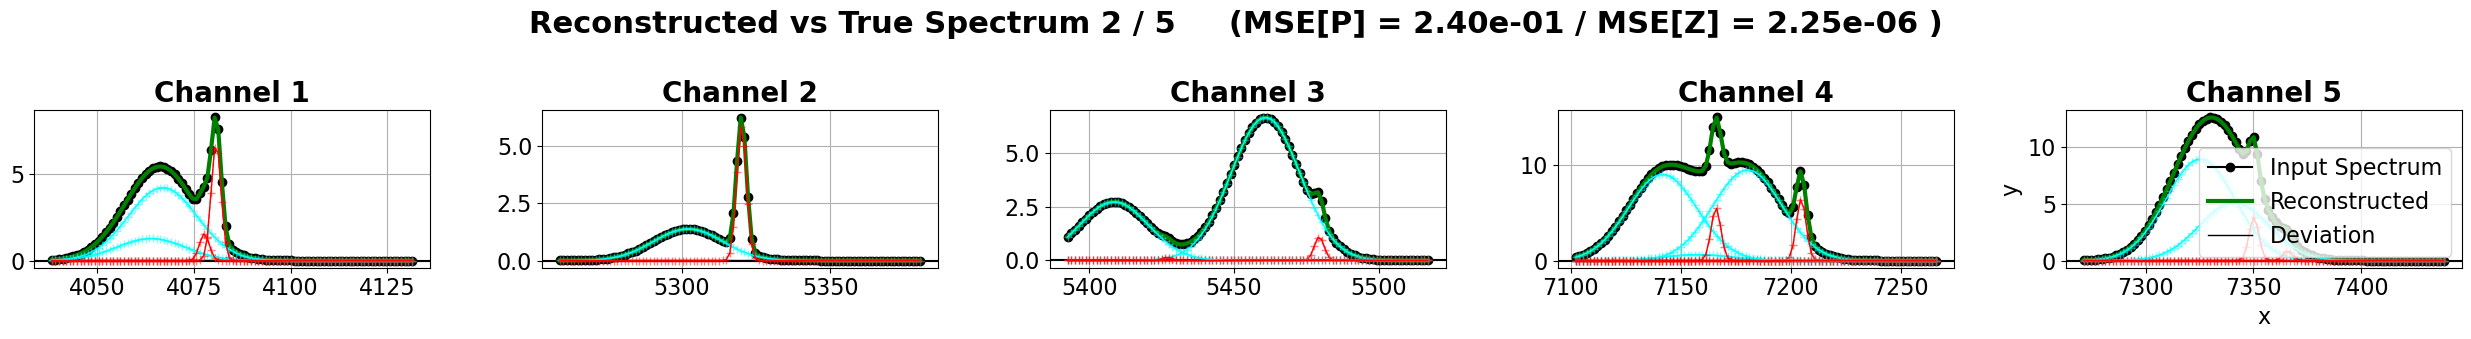

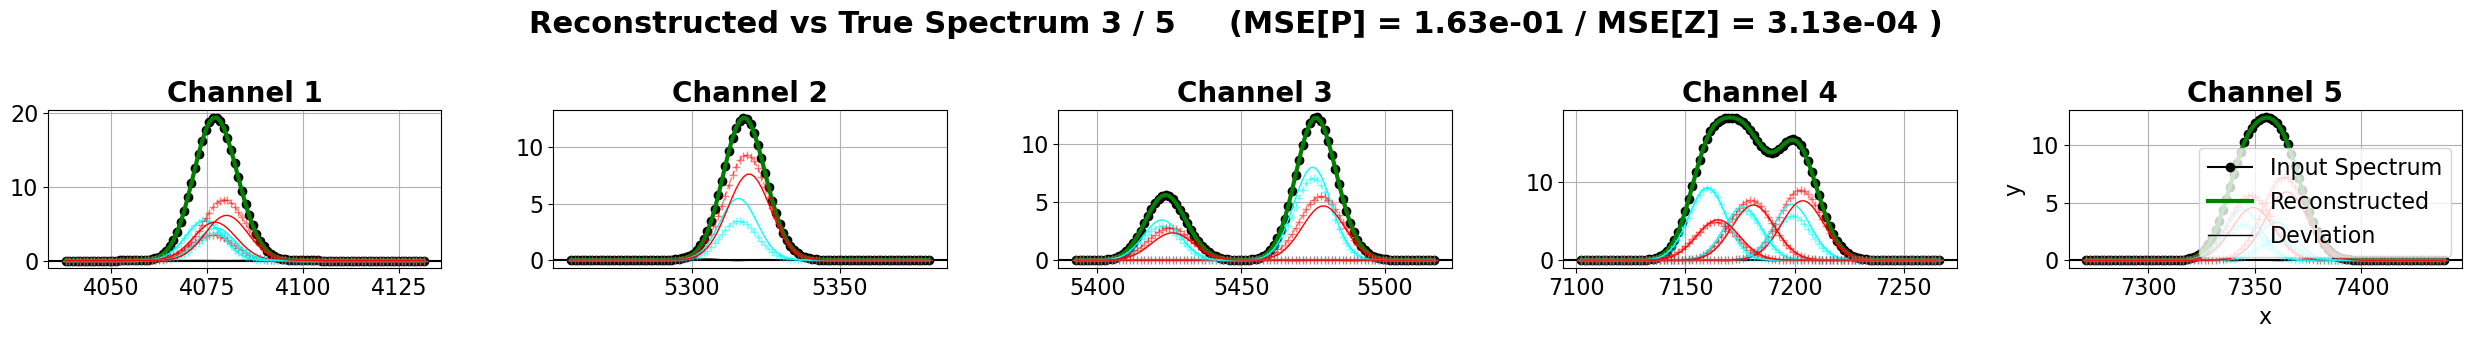

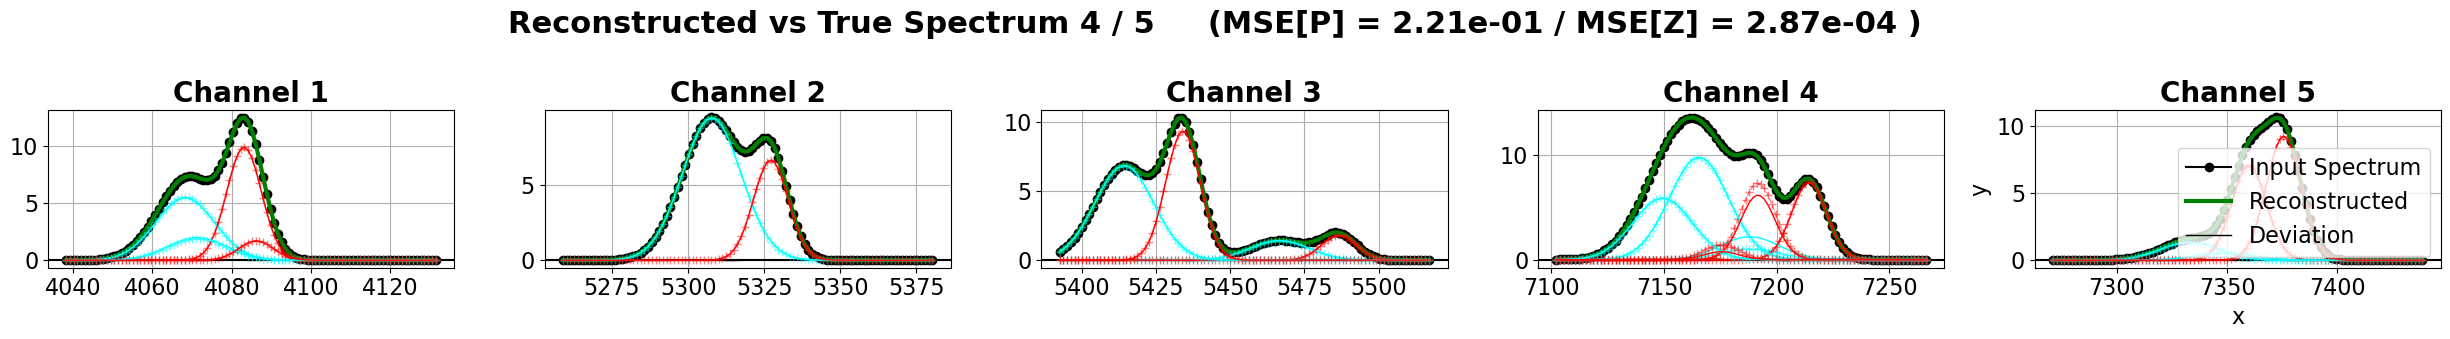

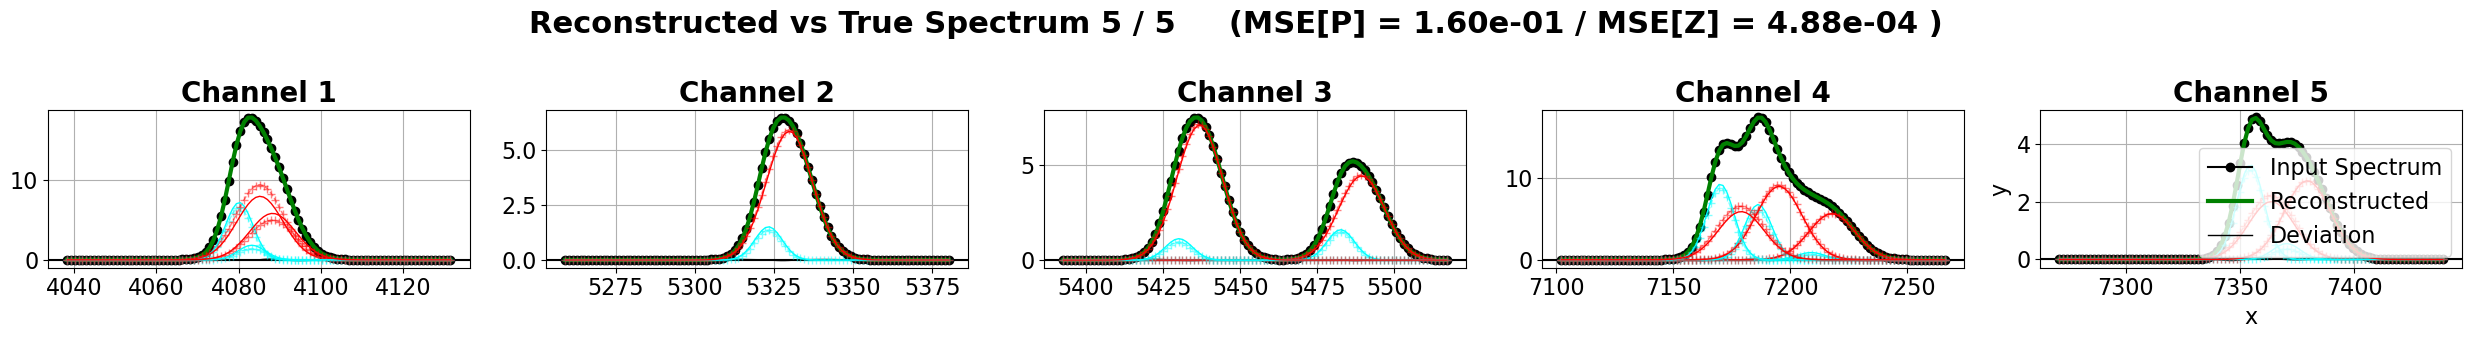

In [18]:
from importlib import reload

# Choose a sample from the train or test data
# signal, params = next(iter(train_loader))
signal, params = next(iter(test_loader))

# Get network prediction
with torch.no_grad():
  model.eval()
  outputs = model(signal)
  
# Extract Gaussians from the outputs and reconstruct predicted spectrum
outputs = gaussian_model.fit(wl, outputs, signal, nsteps=150)  # optimize network output parameters to better fit data
y_pred = gaussian_model.components(wl, outputs)
z_pred = gaussian_model(wl, outputs)

# Extract Gaussians from the targets and reconstruct predicted spectrum
y_true = gaussian_model.components(wl, params)
z_true = gaussian_model(wl, params) # No 

loss = {
  # 'param': F.mse_loss(y_pred, y_true, reduction='none').mean(dim=(1,2,3,4)), # y.shape = (N, C, LpC, KpL, D)
  'param': F.mse_loss(output, params, reduction='none').mean(dim=-1), # params.shape = (N, P)
  'signal': F.mse_loss(z_pred, z_true, reduction='none').mean(dim=(1,2)) # z.shape = (N, C, D)
}

# Convert to numpy
y_true = y_true.cpu().numpy()
z_true = z_true.cpu().numpy()
y_pred = y_pred.cpu().numpy()
z_pred = z_pred.cpu().numpy()
loss = {k: v.cpu().numpy() for k, v in loss.items()}



# Plotting
for n in range(5):
  plt.subplots(nrows=(C+2)//5, ncols = 5, figsize=(25, 3.5))
  plt.suptitle(f'Reconstructed vs True Spectrum {n+1} / {5}     (MSE[P] = {loss["param"][n]:.2e} / MSE[Z] = {loss["signal"][n]:.2e} )')
  for ch_idx, ch in enumerate(channels.values()):
    wl_ch = wl[0, ch_idx, :].cpu().numpy()

    ax = plt.subplot((C+2)//5, 5, ch_idx+1)
    ax.set_title(f'Channel {ch_idx+1}')
    plt.plot(wl_ch, z_true[n, ch_idx], label='Input Spectrum', color='black', marker='o')
    plt.axhline(0, 0, 1, color='black', linestyle='solid')
    plt.plot(wl_ch, z_pred[n, ch_idx], label='Reconstructed', color='green', linestyle='solid', linewidth=3)
    plt.plot(wl_ch, z_true[n, ch_idx] - z_pred[n, ch_idx], label='Deviation', color='black', linestyle='solid', linewidth=1)

    for line_idx, line_name in enumerate(ch.lines):
      for comp_idx, color in zip(range(GpL), ['cyan', 'red']):
        plt.plot(wl_ch, y_true[n, ch_idx, line_idx, comp_idx], linestyle='dashed', marker='+', color=color, alpha=0.5, linewidth=1)
      for comp_idx, color in zip(range(GpL), ['cyan', 'red']):
        plt.plot(wl_ch, y_pred[n, ch_idx, line_idx, comp_idx], linestyle='solid', color=color, linewidth=1)

    plt.grid(True)

  # plt.text(0.99, 0.95, f'MSE = {loss[n]:.2e}', horizontalalignment='right', verticalalignment='top', transform=plt.gca().transAxes)
  plt.xlabel('x')
  plt.ylabel('y')
  plt.legend(loc = 'lower right')
  plt.tight_layout()
  plt.show()

**Step 4:** Apply to real data